In [5]:
# %%writefile train.py
import os
import sys
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import MSELoss
from torch.optim import Adam
from torch.utils.data import Dataset,DataLoader
from scipy.ndimage import zoom
from scipy.interpolate import interp1d

seed = 324
gap_wl = 150
n_resolution = 401
n_pol_train = 100
wl_x = np.linspace(400,800,n_resolution)

nn_inputsize = 448
batchsize = 16
n_epoch = 10

print("Using torch", torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
np.random.seed(seed)
print("Using seed %d"%seed)

class BasicBlock(nn.Module):
    def __init__(self,in_channels,out_channels,stride= 1,expansion = 1,downsample= None):
        super(BasicBlock, self).__init__()
        # Multiplicative factor for the subsequent conv2d layer's output channels.
        # It is 1 for ResNet18 and ResNet34.
        self.expansion = expansion
        self.downsample = downsample
        self.conv1 = nn.Conv2d(
            in_channels, 
            out_channels, 
            kernel_size=3, 
            stride=stride, 
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            out_channels, 
            out_channels*self.expansion, 
            kernel_size=3, 
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels*self.expansion)
        
    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return  out
        
class ResNet18(nn.Module):
    def __init__(self,img_channels=1,block=BasicBlock,num_classes = 1000):
        super(ResNet18, self).__init__()
        num_layers = 18
        layers = [2, 2, 2, 2]
        self.expansion = 1
        
        self.in_channels = 64
        # All ResNets (18 to 152) contain a Conv2d => BN => ReLU for the first
        # three layers. Here, kernel size is 7.
        self.conv1 = nn.Conv2d(
            in_channels=img_channels,
            out_channels=self.in_channels,
            kernel_size=7, 
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))
        self.fc = nn.Linear(2048*self.expansion, num_classes)
        
    def _make_layer(self,block,out_channels,blocks,stride = 1):
        downsample = None
        if stride != 1:
            """
            This should pass from `layer2` to `layer4` or 
            when building ResNets50 and above. Section 3.3 of the paper
            Deep Residual Learning for Image Recognition
            (https://arxiv.org/pdf/1512.03385v1.pdf).
            """
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_channels, 
                    out_channels*self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False 
                ),
                nn.BatchNorm2d(out_channels * self.expansion),
            )
        layers = []
        layers.append(
            block(
                self.in_channels, out_channels, stride, self.expansion, downsample
            )
        )
        self.in_channels = out_channels * self.expansion
        for i in range(1, blocks):
            layers.append(block(
                self.in_channels,
                out_channels,
                expansion=self.expansion
            ))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        # The spatial dimension of the final layer's feature 
        # map should be (7, 7) for all ResNets.
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

def train(model,dataloader,optimizer,loss_fn):
    model.train()
    epoch_loss = 0
    for batch in dataloader:
        cur_x = batch[0].to(device)
        cur_y = batch[1].to(device)
        optimizer.zero_grad()
        y_pred = model(cur_x)
        loss = loss_fn(y_pred, cur_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()*cur_y.shape[0]
    return epoch_loss/len(dataloader)

def evaluate(model,X,y,loss_fn):
    model.eval()
    with torch.no_grad():
        y_pred = model(X)
        loss = loss_fn(y_pred,y).item()
        AE = torch.abs(y_pred-y)
        sep_MAE = np.zeros(4,dtype=np.float32)
        for i in range(4):
            sep_MAE[i] = torch.mean(AE[:,i*n_resolution:(i+1)*n_resolution]).item()
    return loss,sep_MAE
    
    
# in rad
def stokes_from_alphabeta(alpha,beta):
    result = np.zeros((3,alpha.shape[0]),dtype=np.float32)
    result[0] = 0.5*(np.cos(4*alpha-4*beta)+np.cos(4*alpha))
    result[1] = 0.5*(np.sin(4*alpha)-np.sin(4*alpha-4*beta))
    result[2] = -np.sin(4*alpha-2*beta)
    return result
    
class BeamSpliterCorrecter:
    def __init__(self,filename):
        with open(filename,"r") as fo:
            file_list = fo.readlines()
        result=[]
        for i in range(1,len(file_list)):
            temp = file_list[i].strip().split()
            if len(temp)!=4:
                continue
            result.append([float(temp[0]),
                           float(temp[1]),
                           float(temp[2])])
        result = np.array(result)
        self.f_p = interp1d(result[:,0],result[:,1])
        self.f_s = interp1d(result[:,0],result[:,2])
    
    def get_new_alpha(self,wl,alpha,mode="R"):
    
        temp = np.cos(2*alpha)
        symbol = temp/np.abs(temp)
        s_part = np.square(temp)
        p_part = 1-s_part

        if mode=="R":
            ref_intensity = self.f_s(wl)
            s_part = ref_intensity*s_part
            p_part = self.f_p(wl)*p_part

        else:
            ref_intensity = 100-self.f_s(wl)
            s_part = ref_intensity*s_part
            p_part = (100-self.f_p(wl))*p_part

        new_alpha = np.arccos(symbol*np.sqrt(s_part)/np.sqrt(s_part+p_part))/2
        new_intensity = (s_part+p_part)/ref_intensity

        return new_alpha,new_intensity
    
    def __call__(self,wl_x,spec,alpha,beta,lamp=1):
        if lamp == 1:
            new_alpha,new_intensity = self.get_new_alpha(wl_x,alpha,mode="T")
        else:
            new_alpha,new_intensity = self.get_new_alpha(wl_x,alpha,mode="R")
        S123 = stokes_from_alphabeta(new_alpha,beta*np.ones_like(new_alpha))
        result = np.zeros(4*n_resolution,dtype=np.float32)
        result[:wl_x.shape[0]] = spec*new_intensity
        for i in range(3):
            result[(i+1)*wl_x.shape[0]:(i+2)*wl_x.shape[0]] = result[:wl_x.shape[0]]*S123[i]
            
        return result.astype(np.float32)
        
class TwobeamTrain(Dataset):
    def __init__(self):
        print("Loading training set:")
        print("  Reading spectrums...")
        self.spec_correcter = BeamSpliterCorrecter("./5to5.txt")
        self.lamp1_spec_raw,self.lamp1_cwl = self.read_spectrum("./spectrum/lamp1_spectrums.npz")
        self.lamp2_spec_raw,self.lamp2_cwl = self.read_spectrum("./spectrum/lamp2_spectrums.npz")
        self.spec_norm = np.max(self.lamp1_spec_raw)
        self.lamp1_spec_raw = self.lamp1_spec_raw/self.spec_norm
        self.lamp2_spec_raw = self.lamp2_spec_raw/self.spec_norm
        
        print("  Reading lamp1 images...")
        sys.stdout.flush()
        self.lamp1_imgs,self.lamp1_spec = self.get_img_spec(1,self.lamp1_spec_raw)
        print("  Reading lamp2 images...")
        sys.stdout.flush()
        self.lamp2_imgs,self.lamp2_spec = self.get_img_spec(2,self.lamp2_spec_raw)
        print("  Final processing...")
        self.img_norm = np.mean(self.lamp1_imgs)
        self.lamp1_imgs = torch.from_numpy(self.lamp1_imgs/self.img_norm)
        self.lamp2_imgs = torch.from_numpy(self.lamp2_imgs/self.img_norm)
        self.lamp1_spec = torch.from_numpy(self.lamp1_spec)
        self.lamp2_spec = torch.from_numpy(self.lamp2_spec)
        
        # self.aug_idx[i][j] represents i-th lamp2 can augment with aug_idx[i]-th lamp1
        self.aug_idx = []
        self.length = (self.lamp1_spec.shape[0] + self.lamp2_spec.shape[0])*n_pol_train
        for i in range(self.lamp2_cwl.shape[0]):
            self.aug_idx.append(np.argwhere(np.abs(self.lamp1_cwl-self.lamp2_cwl[i])>=gap_wl).reshape(-1))
            self.length += n_pol_train*n_pol_train*self.aug_idx[-1].shape[0]
        
        self.i1_cut = self.lamp1_spec.shape[0]*n_pol_train
        self.i2_cut = self.i1_cut + self.lamp2_spec.shape[0]*n_pol_train
        # i3_cut is a 1d array, indicating lamp2 wl cut. 
        self.i3_cut = np.zeros(len(self.aug_idx),dtype=np.int64)
        for i in range(1,len(self.aug_idx)):
            self.i3_cut[i] = self.i3_cut[i-1] + n_pol_train*n_pol_train*len(self.aug_idx[i-1])
        print("  Finish loading training set")
        sys.stdout.flush()
        
    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        if idx < self.i1_cut:
            wl_i,pol_i = divmod(idx,n_pol_train)
            return self.lamp1_imgs[wl_i,pol_i], self.lamp1_spec[wl_i,pol_i]
        if idx < self.i2_cut:
            wl_i,pol_i = divmod(idx-self.i1_cut,n_pol_train)
            return self.lamp2_imgs[wl_i,pol_i], self.lamp2_spec[wl_i,pol_i]
        
        i3 = idx-self.i2_cut
        l2_wl_i = np.searchsorted(self.i3_cut,i3,side='right') - 1
        l2_pol_i, l1_all_i = divmod(i3-self.i3_cut[l2_wl_i], len(self.aug_idx[l2_wl_i])*n_pol_train)
        l1_wl_i, l1_pol_i = divmod(l1_all_i, n_pol_train)
        
        img = self.lamp1_imgs[self.aug_idx[l2_wl_i][l1_wl_i],l1_pol_i] + self.lamp2_imgs[l2_wl_i, l2_pol_i]
        spec = self.lamp1_spec[self.aug_idx[l2_wl_i][l1_wl_i],l1_pol_i] + self.lamp2_spec[l2_wl_i, l2_pol_i]
        return img,spec
    
    def read_spectrum(self,filename):
        fo = np.load(filename)
        cwl = fo["arr_1"]
        raw_spec = fo["arr_0"]
        spec = np.zeros((raw_spec.shape[0],n_resolution))
        for i in range(raw_spec.shape[0]):
            spec[i] = np.interp(np.linspace(400,800,n_resolution),
                                np.linspace(400,800,raw_spec.shape[1]),
                                raw_spec[i])
        return spec,cwl
    
    def read_img(self,filename):
        fo = np.load(filename)
        raw_imgs = fo["arr_0"]
        exp_array = fo["arr_1"]
        alpha_array = fo["arr_2"]/180*np.pi
        beta_array = fo["arr_3"]/180*np.pi
        imgs = np.zeros((exp_array.shape[0],1,nn_inputsize,nn_inputsize),
                        dtype=np.float32)
        for i in range(exp_array.shape[0]):
            imgs[i,0] = zoom(raw_imgs[i]/exp_array[i],
                            (nn_inputsize/raw_imgs.shape[1],
                             nn_inputsize/raw_imgs.shape[2])).astype(np.float32)
            
        return imgs,alpha_array,beta_array
    
    def get_img_spec(self,lamp,raw_spec):
        file_list = os.listdir("./single/")
        target_files = []
        for i in range(len(file_list)):
            if file_list[i][-4:] == ".npz" and file_list[i].split("_")[0] == "lamp%d"%lamp:
                target_files.append(file_list[i])
        imgs = np.zeros((len(target_files),n_pol_train,
                           1,nn_inputsize,nn_inputsize),
                           dtype=np.float32)
        specs = np.zeros((len(target_files),n_pol_train,4*n_resolution),dtype=np.float32)
        for i in range(len(target_files)):
            imgs[i],alphas,betas = self.read_img("./single/"+target_files[i])
            for j in range(n_pol_train):
                specs[i,j] = self.spec_correcter(wl_x,raw_spec[i],alphas[j],betas[j],lamp=lamp)
            
        return imgs,specs

def get_valtest(training_set):
    print("Loading test and validation sets.")
    file_list = os.listdir("./mix/")
    target_list = []
    for i in range(len(file_list)):
        if file_list[i][-4:] == ".npz":
            target_list.append(file_list[i])
    all_imgs = []
    all_y = []
    for i in range(len(target_list)):
        temp = target_list[i][:-4].split("_")
        lamp1_spec = training_set.lamp1_spec_raw[np.argmin(np.abs(training_set.lamp1_cwl-float(temp[0])))]
        lamp2_spec = training_set.lamp2_spec_raw[np.argmin(np.abs(training_set.lamp2_cwl-float(temp[1])))]
        
        fo = np.load("./mix/"+target_list[i])
        raw_imgs = fo["arr_0"]
        exp_time = fo["arr_1"]
        alpha1_array = fo["arr_2"]/180*np.pi
        alpha2_array = fo["arr_3"]/180*np.pi
        beta_array = fo["arr_4"]/180*np.pi
        imgs = np.zeros((raw_imgs.shape[0],1,nn_inputsize,nn_inputsize),dtype=np.float32)
        ys = np.zeros((raw_imgs.shape[0],4*n_resolution),dtype=np.float32)
        for j in range(raw_imgs.shape[0]):
            imgs[j,0] = zoom(raw_imgs[j]/exp_time[j],
                            (nn_inputsize/raw_imgs.shape[1],
                             nn_inputsize/raw_imgs.shape[2])).astype(np.float32)
            ys[j] += training_set.spec_correcter(wl_x,lamp1_spec,alpha1_array[j],beta_array[j],lamp=1)
            ys[j] += training_set.spec_correcter(wl_x,lamp2_spec,alpha2_array[j],beta_array[j],lamp=2)
        all_imgs.append(imgs)
        all_y.append(ys)
            
    all_imgs = np.concatenate(all_imgs)/training_set.img_norm
    all_y = np.concatenate(all_y)
    
    shuffled_idx = np.arange(all_y.shape[0])
    np.random.shuffle(shuffled_idx)
    cut_i = all_y.shape[0]//2
    x_val = torch.from_numpy(all_imgs[shuffled_idx[:cut_i]]).to(device)
    x_test = torch.from_numpy(all_imgs[shuffled_idx[cut_i:]]).to(device)
    y_val = torch.from_numpy(all_y[shuffled_idx[:cut_i]]).to(device)
    y_test = torch.from_numpy(all_y[shuffled_idx[cut_i:]]).to(device)
    
    return x_val,y_val,x_test,y_test

def run_experiment(task_name,seed_list=[seed],batchsize=batchsize,n_epoch=n_epoch,save_dir="./ML_result/"):
    result_name = ["train_loss",
                   "val_loss","val_S0","val_S1","val_S2","val_S3",
                   "test_loss","test_S0","test_S1","test_S2","test_S3"]
    if not os.path.exists(save_dir):
        os.mkdir(save_dir)
    print("Running %s"%task_name)
    for seed in seed_list:
        print("Seed %d"%seed)
        sys.stdout.flush()
        torch.manual_seed(seed)
        train_loader = DataLoader(training_set,batch_size=batchsize, shuffle=True)
        model=ResNet18(num_classes=n_resolution*4).to(device)
        loss_fn=MSELoss()
        optimizer=Adam(model.parameters(),lr=0.0001)
        result=np.zeros((n_epoch,11),dtype=np.float32)
        for i in range(n_epoch):
            result[i,0] = train(model,train_loader,optimizer,loss_fn)
            result[i,1],result[i,2:6] = evaluate(model,x_val,y_val,loss_fn)
            result[i,6],result[i,7:] = evaluate(model,x_test,y_test,loss_fn)
            print(i,result)
            sys.stdout.flush()
            torch.save(model,save_dir+task_name+"_seed%d_epoch%d"%(seed,i+1) + ".pt")
        result = pd.DataFrame(result,columns=result_name)
        save_filename=save_dir+task_name+"_seed%d"%seed+".csv"
        result.to_csv(save_filename,index=False)
        
training_set = TwobeamTrain()
x_val,y_val,x_test,y_test = get_valtest(training_set)
#run_experiment("Resnet18")
print("All finished!")

Using torch 2.5.1
Using device: cpu
Using seed 324
Loading training set:
  Reading spectrums...
  Reading lamp1 images...
  Reading lamp2 images...
  Final processing...
  Finish loading training set
Loading test and validation sets.
All finished!


In [16]:
len(training_set)

2979200

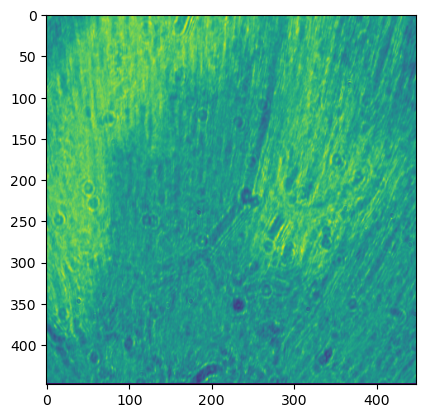

In [6]:
import matplotlib.pyplot as plt
idx = 2200000
plt.imshow(training_set[idx][0][0])

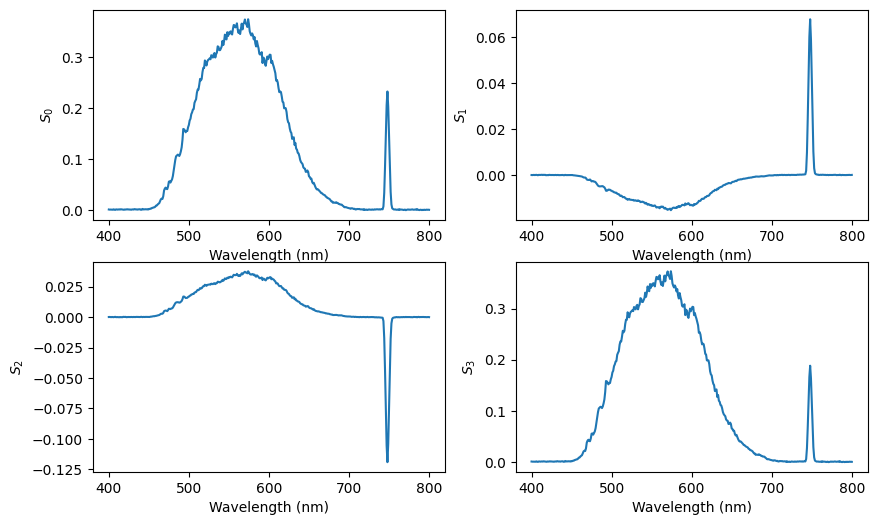

In [4]:
f, axs = plt.subplots(2,2,figsize=(10,6))
for i in range(4):
    axs_y = i//2
    axs_x = i%2
    axs[axs_y,axs_x].plot(wl_x,training_set[idx][1][i*wl_x.shape[0]:(i+1)*wl_x.shape[0]])
    axs[axs_y,axs_x].set_ylabel(r"$S_{%d}$"%i)
    axs[axs_y,axs_x].set_xlabel("Wavelength (nm)")

In [33]:
x_val = x_val.to("cpu").numpy()
y_val = y_val.to("cpu").numpy()
x_test = x_test.to("cpu").numpy()
y_test = y_test.to("cpu").numpy()

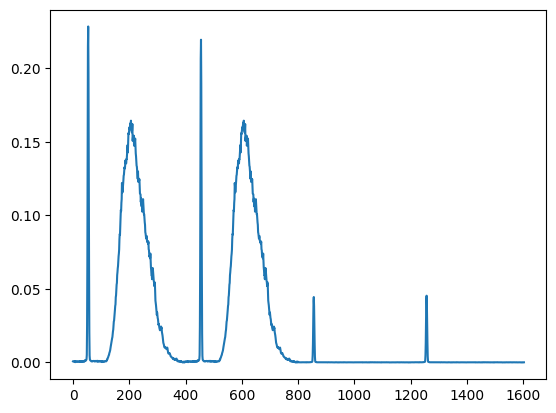

In [34]:
a = training_set.lamp1_spec_raw[np.argmin(np.abs(training_set.lamp1_cwl-450))]
b = training_set.lamp2_spec_raw[np.argmin(np.abs(training_set.lamp2_cwl-750))]
result = training_set.spec_correcter(wl_x,a,0,0.1,lamp=1)+training_set.spec_correcter(wl_x,b,0,0,lamp=2)
plt.plot(result)


In [35]:
np.savez_compressed("testval.npz",x_val,y_val,x_test,y_test)

# Post-processing

In [ ]:
import numpy as np
import torch
from torch import nn

seed = 324
n_resolution = 401
wl_x = np.linspace(400,800,401)

print("Using torch", torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
np.random.seed(seed)
print("Using seed %d"%seed)

fo = np.load("testval.npz")
x_val = fo["arr_0"]
y_val = fo["arr_1"]
x_test = fo["arr_2"]
y_test = fo["arr_3"]
x_test = torch.from_numpy(x_test).to(device)


class BasicBlock(nn.Module):
    def __init__(self,in_channels,out_channels,stride= 1,expansion = 1,downsample= None):
        super(BasicBlock, self).__init__()
        # Multiplicative factor for the subsequent conv2d layer's output channels.
        # It is 1 for ResNet18 and ResNet34.
        self.expansion = expansion
        self.downsample = downsample
        self.conv1 = nn.Conv2d(
            in_channels, 
            out_channels, 
            kernel_size=3, 
            stride=stride, 
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            out_channels, 
            out_channels*self.expansion, 
            kernel_size=3, 
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels*self.expansion)
        
    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return  out
        
class ResNet18(nn.Module):
    def __init__(self,img_channels=1,block=BasicBlock,num_classes = 1000):
        super(ResNet18, self).__init__()
        num_layers = 18
        layers = [2, 2, 2, 2]
        self.expansion = 1
        
        self.in_channels = 64
        # All ResNets (18 to 152) contain a Conv2d => BN => ReLU for the first
        # three layers. Here, kernel size is 7.
        self.conv1 = nn.Conv2d(
            in_channels=img_channels,
            out_channels=self.in_channels,
            kernel_size=7, 
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))
        self.fc = nn.Linear(2048*self.expansion, num_classes)
        
    def _make_layer(self,block,out_channels,blocks,stride = 1):
        downsample = None
        if stride != 1:
            """
            This should pass from `layer2` to `layer4` or 
            when building ResNets50 and above. Section 3.3 of the paper
            Deep Residual Learning for Image Recognition
            (https://arxiv.org/pdf/1512.03385v1.pdf).
            """
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_channels, 
                    out_channels*self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False 
                ),
                nn.BatchNorm2d(out_channels * self.expansion),
            )
        layers = []
        layers.append(
            block(
                self.in_channels, out_channels, stride, self.expansion, downsample
            )
        )
        self.in_channels = out_channels * self.expansion
        for i in range(1, blocks):
            layers.append(block(
                self.in_channels,
                out_channels,
                expansion=self.expansion
            ))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        # The spatial dimension of the final layer's feature 
        # map should be (7, 7) for all ResNets.
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
    
model = torch.load("./ML_result/Resnet18_seed324_epoch4.pt",map_location=device)
model.to(device)
y_pred = model(x_test).detach().to("cpu").numpy()

Using torch 2.5.1
Using device: cpu
Using seed 324


/var/folders/dx/ypjj7qg52dg6jk1ct493lg2c0000gn/T/ipykernel_4892/1732875023.py:139: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("./ML_result/Resnet18_see

In [ ]:
n_resolution = 401
def l1_relative_error(predicted, true):
    numerator = np.sum(np.abs(predicted - true),-1)
    #denominator = np.sum(np.abs(true),-1)
    denominator = n_resolution*np.max(np.abs(true),-1)
    return numerator / denominator

for i in range(4):
    cur_pred = y_pred[:,i*n_resolution:(i+1)*n_resolution]
    cur_test = y_test[:,i*n_resolution:(i+1)*n_resolution]
    l1 = l1_relative_error(cur_pred,cur_test)
    print(l1)
np.savez_compressed("./y_pred.npz",y_test,y_pred)

[0.00459665 0.00608441 0.00297837 0.00829057 0.0336585  0.00389449
 0.00587072 0.01153996 0.02884552 0.00956797 0.00338684 0.01417908
 0.02283649 0.00324157 0.03712971 0.01418487 0.04643192 0.00461491
 0.0292428  0.00467455 0.0108479  0.00588415 0.02647424 0.00719934
 0.00946671 0.00539612 0.0037324  0.00524046 0.00753203 0.0113948
 0.01121145 0.01418846 0.0048678  0.01591926 0.00854153 0.01336547
 0.0039985  0.00436511 0.03070812 0.00774402 0.0146336  0.00432095
 0.03464496 0.03630575 0.01216495]
[3.16275731e-02 1.46574741e-02 9.40169115e-03 1.63199175e-02
 6.85840622e-02 6.16083965e-02 2.55945604e-02 5.10509275e-02
 1.10782986e+01 1.90873332e-02 4.40982915e-03 2.85112858e-02
 2.56340373e-02 7.62838777e-03 2.52086967e-02 4.59745228e-02
 7.10492730e-02 8.82944092e-03 1.03916757e-01 5.16676204e-03
 1.76765844e-02 2.83609152e-01 4.38393503e-02 1.32831950e-02
 3.59459788e-01 1.03068026e-02 6.24506455e-03 1.46475397e-02
 3.90543714e-02 4.97372933e-02 4.61413711e-02 6.67896196e-02
 8.030475

# Plot

In [1]:
import numpy as np
fo = np.load("./y_pred.npz")
y_test = fo["arr_0"]
y_pred = fo["arr_1"]
n_resolution = 401
print(y_test.shape)

good_points = [i for i in range(8)] + [i for i in range(9,45)]

def calc_error(y0,yr):
    result = np.zeros(4)
    max_i = np.argmax(y0[:401])
    
    result[0] = np.mean(np.square((y0[:401]-yr[:401])/y0[max_i]))
    
    for i in range(1,4):
        result[i] = np.mean(np.square((y0[i*401:(i+1)*401]-yr[i*401:(i+1)*401])/y0[max_i]))
    
    return np.sqrt(result)

def calc_error_old(y0,yr):
    result = np.zeros(4)
    max_i = np.argmax(y0[:401])
    result[0] = np.sum(np.abs(y0[:401]-yr[:401]))/np.sum(np.abs(y0[:401]))
    
    for i in range(1,4):
        result[i] = np.sum(np.abs(y0[i*401:(i+1)*401]-yr[i*401:(i+1)*401]))/np.sum(np.abs(y0[:401]))
    
    return result

result = np.zeros(4)
for i in good_points:
    result += calc_error(y_test[i],y_pred[i])

result = result/len(good_points)
result

(45, 1604)


array([0.03262256, 0.02899631, 0.02766838, 0.0265722 ])

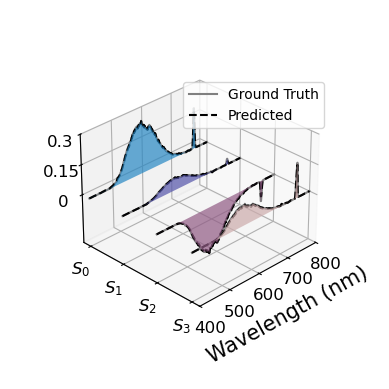

In [54]:
import matplotlib.pyplot as plt
import numpy as np

idx=1
colors = ["#2787C3", "#5454AA", "#905A84", "#CDABAC", "#A2B0A2", '#778899', '#696969']

fo = np.load("./y_pred.npz")
y_test = fo["arr_0"]
y_pred = fo["arr_1"]
wl_x = np.linspace(400,800,401)

ax = plt.figure().add_subplot(projection='3d')
for i in range(4):
    ys = np.ones_like(wl_x)*i
    ax.fill_between(wl_x, ys, y_test[idx,i*401:(i+1)*401],
                    wl_x, ys, 0,
                    facecolors=colors[i], alpha=.7)
    if i == 0:
        ax.plot(wl_x,ys,zs=y_test[idx][i*401:(i+1)*401],c="gray",label="Ground Truth")
        ax.plot(wl_x,ys,zs=y_pred[idx][i*401:(i+1)*401],ls="--",color="black",label="Predicted")
    else:
        ax.plot(wl_x,ys,zs=y_test[idx][i*401:(i+1)*401],c="gray")
        ax.plot(wl_x,ys,zs=y_pred[idx][i*401:(i+1)*401],ls="--",color="black")
ax.view_init(elev=30, azim=45, roll=0)
ax.set_xlim(800,400)
ax.set_xticks([400,500,600,700,800],[str(i) for i in [400,500,600,700,800]],fontsize=12)
ax.set_yticks([0,1,2,3],[r"$S_%d$"%i for i in [0,1,2,3]],fontsize=12,)
ax.set_zticks([0,0.15,0.3],[str(i) for i in [0,0.15,0.3]],fontsize=12,)
#ax.tick_params(axis='both', which='major', pad=2)


ax.set_xlabel("Wavelength (nm)",fontsize=15,labelpad=12)
ax.set_box_aspect(None, zoom=0.7)
ax.legend(bbox_to_anchor=(0.45,0.66))


plt.savefig("beam%d.svg"%idx,transparent=True, bbox_inches='tight')

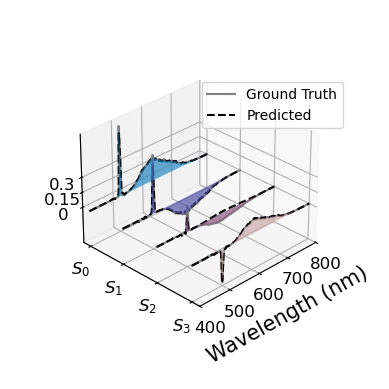

In [53]:
import matplotlib.pyplot as plt
import numpy as np

idx=-20
colors = ["#2787C3", "#5454AA", "#905A84", "#CDABAC", "#A2B0A2", '#778899', '#696969']

fo = np.load("./y_pred.npz")
y_test = fo["arr_0"]
y_pred = fo["arr_1"]
wl_x = np.linspace(400,800,401)

ax = plt.figure().add_subplot(projection='3d')
for i in range(4):
    ys = np.ones_like(wl_x)*i
    ax.fill_between(wl_x, ys, y_test[idx,i*401:(i+1)*401],
                    wl_x, ys, 0,
                    facecolors=colors[i], alpha=.7)
    if i == 0:
        ax.plot(wl_x,ys,zs=y_test[idx][i*401:(i+1)*401],c="gray",label="Ground Truth")
        ax.plot(wl_x,ys,zs=y_pred[idx][i*401:(i+1)*401],ls="--",color="black",label="Predicted")
    else:
        ax.plot(wl_x,ys,zs=y_test[idx][i*401:(i+1)*401],c="gray")
        ax.plot(wl_x,ys,zs=y_pred[idx][i*401:(i+1)*401],ls="--",color="black")
ax.view_init(elev=30, azim=45, roll=0)
ax.set_xlim(800,400)
ax.set_xticks([400,500,600,700,800],[str(i) for i in [400,500,600,700,800]],fontsize=12)
ax.set_yticks([0,1,2,3],[r"$S_%d$"%i for i in [0,1,2,3]],fontsize=12,)
ax.set_zticks([0,0.15,0.3],[str(i) for i in[0,0.15,0.3]],fontsize=12)
#ax.tick_params(axis='both', which='major', pad=2)


ax.set_xlabel("Wavelength (nm)",fontsize=15,labelpad=12)
ax.set_box_aspect(None, zoom=0.7)
ax.legend(bbox_to_anchor=(0.5,0.66))


plt.savefig("beam%d.svg"%idx,transparent=True, bbox_inches='tight')

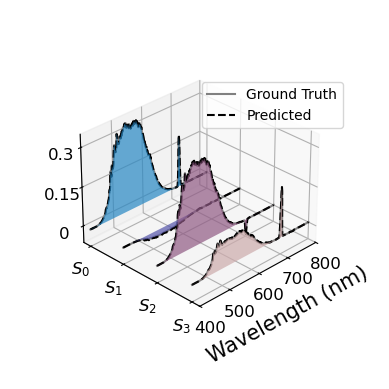

In [14]:
import matplotlib.pyplot as plt
import numpy as np

idx=5
colors = ["#2787C3", "#5454AA", "#905A84", "#CDABAC", "#A2B0A2", '#778899', '#696969']

fo = np.load("./y_pred.npz")
y_test = fo["arr_0"]
y_pred = fo["arr_1"]
wl_x = np.linspace(400,800,401)

ax = plt.figure().add_subplot(projection='3d')
for i in range(4):
    ys = np.ones_like(wl_x)*i
    ax.fill_between(wl_x, ys, y_test[idx,i*401:(i+1)*401],
                    wl_x, ys, 0,
                    facecolors=colors[i], alpha=.7)
    if i == 0:
        ax.plot(wl_x,ys,zs=y_test[idx][i*401:(i+1)*401],c="gray",label="Ground Truth")
        ax.plot(wl_x,ys,zs=y_pred[idx][i*401:(i+1)*401],ls="--",color="black",label="Predicted")
    else:
        ax.plot(wl_x,ys,zs=y_test[idx][i*401:(i+1)*401],c="gray")
        ax.plot(wl_x,ys,zs=y_pred[idx][i*401:(i+1)*401],ls="--",color="black")
ax.view_init(elev=30, azim=45, roll=0)
ax.set_xlim(800,400)
ax.set_xticks([400,500,600,700,800],[str(i) for i in [400,500,600,700,800]],fontsize=12)
ax.set_yticks([0,1,2,3],[r"$S_%d$"%i for i in [0,1,2,3]],fontsize=12,)
ax.set_zticks([0,0.15,0.3],[str(i) for i in[0,0.15,0.3]],fontsize=12)
#ax.tick_params(axis='both', which='major', pad=2)


ax.set_xlabel("Wavelength (nm)",fontsize=15,labelpad=12)
ax.set_box_aspect(None, zoom=0.7)
ax.legend(bbox_to_anchor=(0.5,0.66))

# New plot

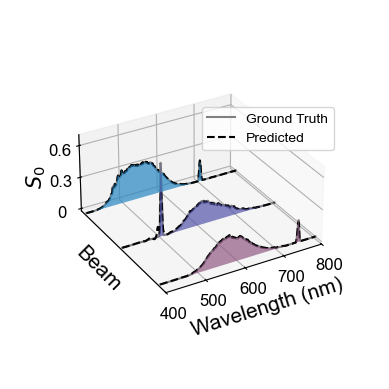

In [101]:
import matplotlib.pyplot as plt
import numpy as np

plot_idx = [5,20,1]
colors = ["#2787C3", "#5454AA", "#905A84", "#CDABAC", "#A2B0A2", '#778899', '#696969']
plt.rcParams['font.sans-serif'] = ['Arial']

fo = np.load("./y_pred.npz")
y_test = fo["arr_0"]
y_pred = fo["arr_1"]
wl_x = np.linspace(400,800,401)

ax = plt.figure().add_subplot(projection='3d')
i=0
for j in range(len(plot_idx)):
    ys = np.ones_like(wl_x)*j
    idx = plot_idx[j]
    ax.fill_between(wl_x, ys, y_test[idx,i*401:(i+1)*401],
                    wl_x, ys, 0,
                    facecolors=colors[j], alpha=.7)
    if j == 0:
        ax.plot(wl_x,ys,zs=y_test[idx][i*401:(i+1)*401],c="gray",label="Ground Truth")
        ax.plot(wl_x,ys,zs=y_pred[idx][i*401:(i+1)*401],ls="--",color="black",label="Predicted")
    else:
        ax.plot(wl_x,ys,zs=y_test[idx][i*401:(i+1)*401],c="gray")
        ax.plot(wl_x,ys,zs=y_pred[idx][i*401:(i+1)*401],ls="--",color="black")
ax.view_init(elev=30, azim=60, roll=0)
ax.set_xlim(800,400)
ax.set_xticks([400,500,600,700,800],[str(i) for i in [400,500,600,700,800]],fontsize=12)
ax.set_yticks([],[])
ax.set_zticks([0,0.3,0.6],[str(i) for i in[0,0.3,0.6]],fontsize=12)
#ax.tick_params(axis='both', which='major', pad=2)
ax.text2D(0.04, 0.53, r"$S_%d$"%i, transform=ax.transAxes, rotation=90,fontsize=15)
#ax.set_zlabel(r"$S_0$",fontsize=15,labelpad=10,rotation=90)
ax.set_xlabel("Wavelength (nm)",fontsize=15,labelpad=12)
ax.set_ylabel("Beam",fontsize=15,labelpad=0,rotation=-45)

ax.set_box_aspect([1,1,0.5], zoom=0.7)
ax.legend(bbox_to_anchor=(0.5,0.6))
plt.savefig("S%d.svg"%i,transparent=True, bbox_inches='tight')

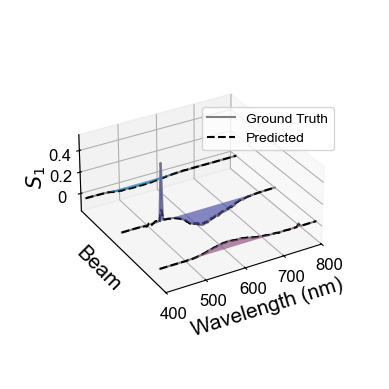

In [107]:
import matplotlib.pyplot as plt
import numpy as np

plot_idx = [5,20,1]
colors = ["#2787C3", "#5454AA", "#905A84", "#CDABAC", "#A2B0A2", '#778899', '#696969']
plt.rcParams['font.sans-serif'] = ['Arial']

fo = np.load("./y_pred.npz")
y_test = fo["arr_0"]
y_pred = fo["arr_1"]
wl_x = np.linspace(400,800,401)

ax = plt.figure().add_subplot(projection='3d')
i=1
for j in range(len(plot_idx)):
    ys = np.ones_like(wl_x)*j
    idx = plot_idx[j]
    ax.fill_between(wl_x, ys, y_test[idx,i*401:(i+1)*401],
                    wl_x, ys, 0,
                    facecolors=colors[j], alpha=.7)
    if j == 0:
        ax.plot(wl_x,ys,zs=y_test[idx][i*401:(i+1)*401],c="gray",label="Ground Truth")
        ax.plot(wl_x,ys,zs=y_pred[idx][i*401:(i+1)*401],ls="--",color="black",label="Predicted")
    else:
        ax.plot(wl_x,ys,zs=y_test[idx][i*401:(i+1)*401],c="gray")
        ax.plot(wl_x,ys,zs=y_pred[idx][i*401:(i+1)*401],ls="--",color="black")
ax.view_init(elev=30, azim=60, roll=0)
ax.set_xlim(800,400)
ax.set_xticks([400,500,600,700,800],[str(i) for i in [400,500,600,700,800]],fontsize=12)
ax.set_yticks([],[])
ax.set_zticks([0,0.2,0.4],[str(i) for i in[0,0.2,0.4]],fontsize=12)
#ax.tick_params(axis='both', which='major', pad=2)
ax.text2D(0.04, 0.53, r"$S_%d$"%i, transform=ax.transAxes, rotation=90,fontsize=15)
#ax.set_zlabel(r"$S_0$",fontsize=15,labelpad=10,rotation=90)
ax.set_xlabel("Wavelength (nm)",fontsize=15,labelpad=12)
ax.set_ylabel("Beam",fontsize=15,labelpad=0,rotation=-45)

ax.set_box_aspect([1,1,0.5], zoom=0.7)
ax.legend(bbox_to_anchor=(0.5,0.6))
plt.savefig("S%d.svg"%i,transparent=True, bbox_inches='tight')

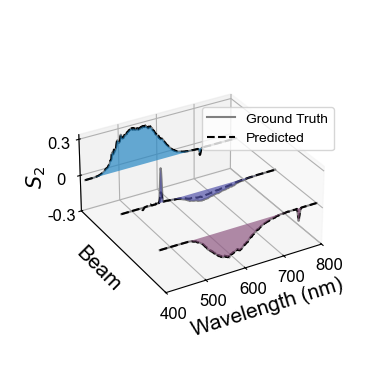

In [109]:
import matplotlib.pyplot as plt
import numpy as np

plot_idx = [5,20,1]
colors = ["#2787C3", "#5454AA", "#905A84", "#CDABAC", "#A2B0A2", '#778899', '#696969']
plt.rcParams['font.sans-serif'] = ['Arial']

fo = np.load("./y_pred.npz")
y_test = fo["arr_0"]
y_pred = fo["arr_1"]
wl_x = np.linspace(400,800,401)

ax = plt.figure().add_subplot(projection='3d')
i=2
for j in range(len(plot_idx)):
    ys = np.ones_like(wl_x)*j
    idx = plot_idx[j]
    ax.fill_between(wl_x, ys, y_test[idx,i*401:(i+1)*401],
                    wl_x, ys, 0,
                    facecolors=colors[j], alpha=.7)
    if j == 0:
        ax.plot(wl_x,ys,zs=y_test[idx][i*401:(i+1)*401],c="gray",label="Ground Truth")
        ax.plot(wl_x,ys,zs=y_pred[idx][i*401:(i+1)*401],ls="--",color="black",label="Predicted")
    else:
        ax.plot(wl_x,ys,zs=y_test[idx][i*401:(i+1)*401],c="gray")
        ax.plot(wl_x,ys,zs=y_pred[idx][i*401:(i+1)*401],ls="--",color="black")
ax.view_init(elev=30, azim=60, roll=0)
ax.set_xlim(800,400)
ax.set_xticks([400,500,600,700,800],[str(i) for i in [400,500,600,700,800]],fontsize=12)
ax.set_yticks([],[])
ax.set_zticks([-0.3,0,0.3],[str(i) for i in[-0.3,0,0.3]],fontsize=12)
#ax.tick_params(axis='both', which='major', pad=2)
ax.text2D(0.04, 0.53, r"$S_%d$"%i, transform=ax.transAxes, rotation=90,fontsize=15)
#ax.set_zlabel(r"$S_0$",fontsize=15,labelpad=10,rotation=90)
ax.set_xlabel("Wavelength (nm)",fontsize=15,labelpad=12)
ax.set_ylabel("Beam",fontsize=15,labelpad=0,rotation=-45)

ax.set_box_aspect([1,1,0.5], zoom=0.7)
ax.legend(bbox_to_anchor=(0.5,0.6))
plt.savefig("S%d.svg"%i,transparent=True, bbox_inches='tight')

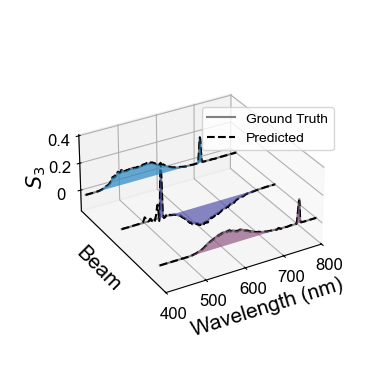

In [111]:
import matplotlib.pyplot as plt
import numpy as np

plot_idx = [5,20,1]
colors = ["#2787C3", "#5454AA", "#905A84", "#CDABAC", "#A2B0A2", '#778899', '#696969']
plt.rcParams['font.sans-serif'] = ['Arial']

fo = np.load("./y_pred.npz")
y_test = fo["arr_0"]
y_pred = fo["arr_1"]
wl_x = np.linspace(400,800,401)

ax = plt.figure().add_subplot(projection='3d')
i=3
for j in range(len(plot_idx)):
    ys = np.ones_like(wl_x)*j
    idx = plot_idx[j]
    ax.fill_between(wl_x, ys, y_test[idx,i*401:(i+1)*401],
                    wl_x, ys, 0,
                    facecolors=colors[j], alpha=.7)
    if j == 0:
        ax.plot(wl_x,ys,zs=y_test[idx][i*401:(i+1)*401],c="gray",label="Ground Truth")
        ax.plot(wl_x,ys,zs=y_pred[idx][i*401:(i+1)*401],ls="--",color="black",label="Predicted")
    else:
        ax.plot(wl_x,ys,zs=y_test[idx][i*401:(i+1)*401],c="gray")
        ax.plot(wl_x,ys,zs=y_pred[idx][i*401:(i+1)*401],ls="--",color="black")
ax.view_init(elev=30, azim=60, roll=0)
ax.set_xlim(800,400)
ax.set_xticks([400,500,600,700,800],[str(i) for i in [400,500,600,700,800]],fontsize=12)
ax.set_yticks([],[])
ax.set_zticks([0,0.2,0.4],[str(i) for i in[0,0.2,0.4]],fontsize=12)
#ax.tick_params(axis='both', which='major', pad=2)
ax.text2D(0.04, 0.53, r"$S_%d$"%i, transform=ax.transAxes, rotation=90,fontsize=15)
#ax.set_zlabel(r"$S_0$",fontsize=15,labelpad=10,rotation=90)
ax.set_xlabel("Wavelength (nm)",fontsize=15,labelpad=12)
ax.set_ylabel("Beam",fontsize=15,labelpad=0,rotation=-45)

ax.set_box_aspect([1,1,0.5], zoom=0.7)
ax.legend(bbox_to_anchor=(0.5,0.6))
plt.savefig("S%d.svg"%i,transparent=True, bbox_inches='tight')